In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, MSTL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('weatherHistory.csv')

In [4]:
print(f"Размер датасета: {df.shape}")

Размер датасета: (96453, 12)


In [5]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [6]:
df['Datetime'] = pd.to_datetime(df['Formatted Date'])
df = df.set_index('Datetime').sort_index()
print("Тип индекса после преобразования:", type(df.index))

Тип индекса после преобразования: <class 'pandas.core.indexes.base.Index'>


C:\Users\rabts\AppData\Local\Temp\ipykernel_11152\3097834197.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Datetime'] = pd.to_datetime(df['Formatted Date'])


In [7]:
duplicate_count = df.index.duplicated().sum()
print(f"Количество дублирующихся меток времени: {duplicate_count}")

if duplicate_count > 0:
    df = df.groupby(level=0).mean(numeric_only=True)
    print("Дубликаты устранены методом усреднения.")

Количество дублирующихся меток времени: 24
Дубликаты устранены методом усреднения.


In [8]:
all_hours = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(all_hours)
df['Temperature (C)'] = df['Temperature (C)'].interpolate(method='linear')

print(f"Количество восстановленных пропусков: {len(all_hours) - (len(df) - df['Temperature (C)'].isna().sum())}")

Количество восстановленных пропусков: 0


In [9]:
def check_stationarity(series):
    result = adfuller(series.values)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4e}')
    if result[1] <= 0.05:
        print("Вывод: Ряд стационарен (нулевая гипотеза отвергнута).")
    else:
        print("Вывод: Ряд нестационарен (нулевая гипотеза не отвергнута).")

check_stationarity(df['Temperature (C)'])

ADF Statistic: -7.3991
p-value: 7.6380e-11
Вывод: Ряд стационарен (нулевая гипотеза отвергнута).


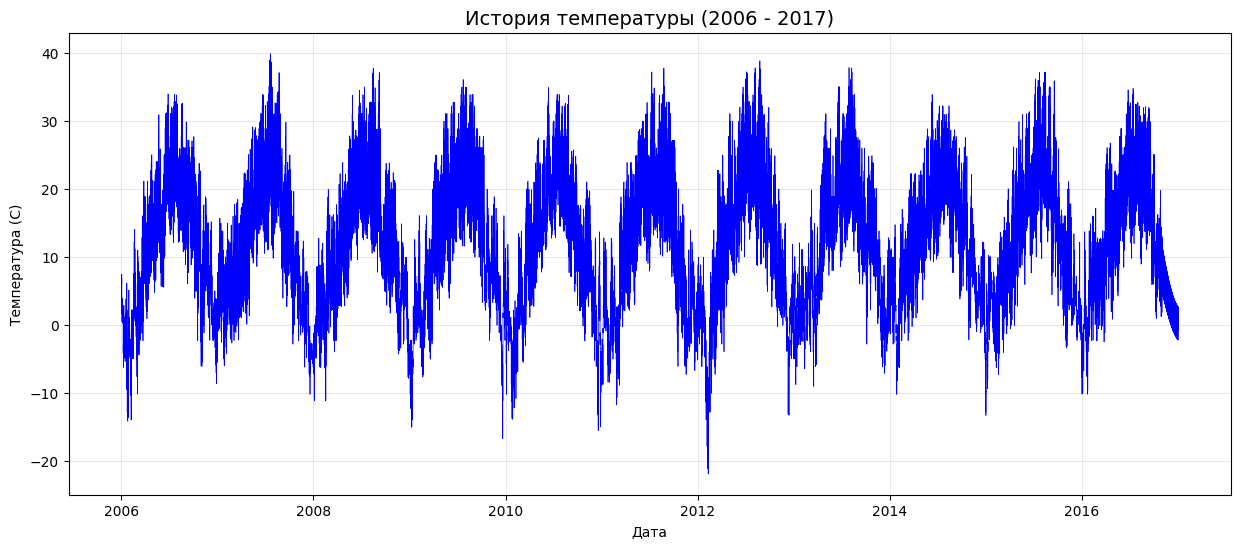

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Temperature (C)'], color='blue', linewidth=0.5)

plt.title('История температуры (2006 - 2017)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура (C)')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
df = df[df.index < '2016-06-30']

print(f"Новый размер датасета: {df.shape}")
print(f"Последняя дата в данных: {df.index.max()}")

Новый размер датасета: (91992, 8)
Последняя дата в данных: 2016-06-29 23:00:00+01:00


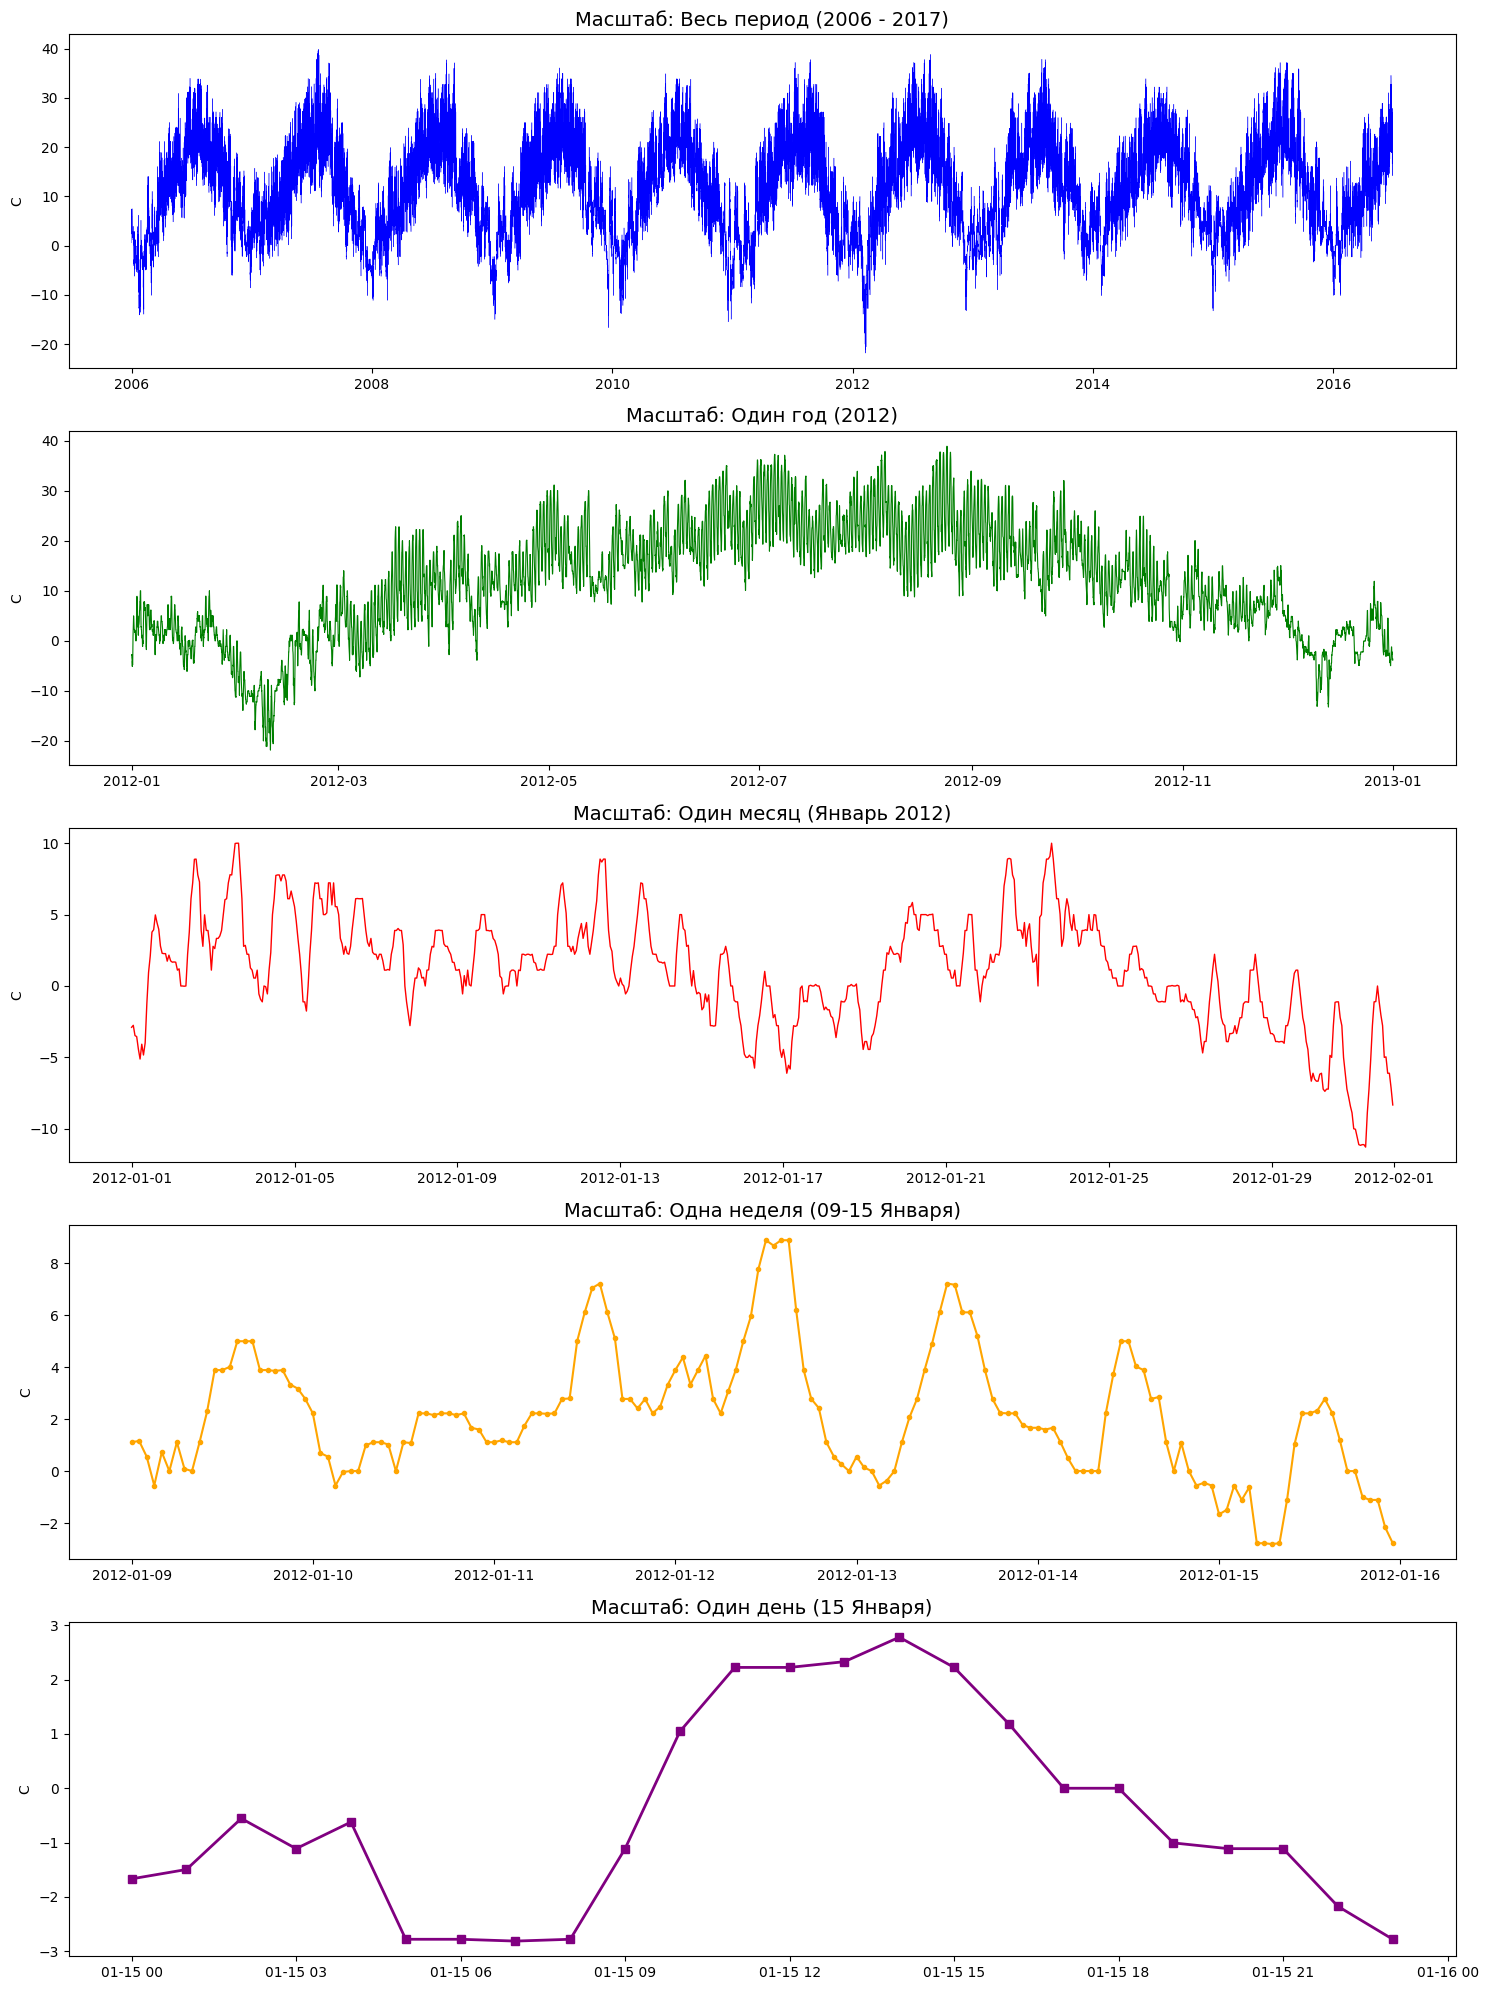

In [11]:
fig, axes = plt.subplots(5, 1, figsize=(15, 20))

axes[0].plot(df.index, df['Temperature (C)'], color='blue', linewidth=0.3)
axes[0].set_title('Масштаб: Весь период (2006 - 2017)', fontsize=14)

df_year = df.loc['2012']
axes[1].plot(df_year.index, df_year['Temperature (C)'], color='green', linewidth=0.8)
axes[1].set_title('Масштаб: Один год (2012)', fontsize=14)

df_month = df.loc['2012-01']
axes[2].plot(df_month.index, df_month['Temperature (C)'], color='red', linewidth=1)
axes[2].set_title('Масштаб: Один месяц (Январь 2012)', fontsize=14)

df_week = df.loc['2012-01-09':'2012-01-15']
axes[3].plot(df_week.index, df_week['Temperature (C)'], color='orange', linewidth=1.5, marker='o', markersize=3)
axes[3].set_title('Масштаб: Одна неделя (09-15 Января)', fontsize=14)

df_day = df.loc['2012-01-15']
axes[4].plot(df_day.index, df_day['Temperature (C)'], color='purple', linewidth=2, marker='s')
axes[4].set_title('Масштаб: Один день (15 Января)', fontsize=14)

for ax in axes:
    ax.set_ylabel('C')

plt.tight_layout()
plt.show()

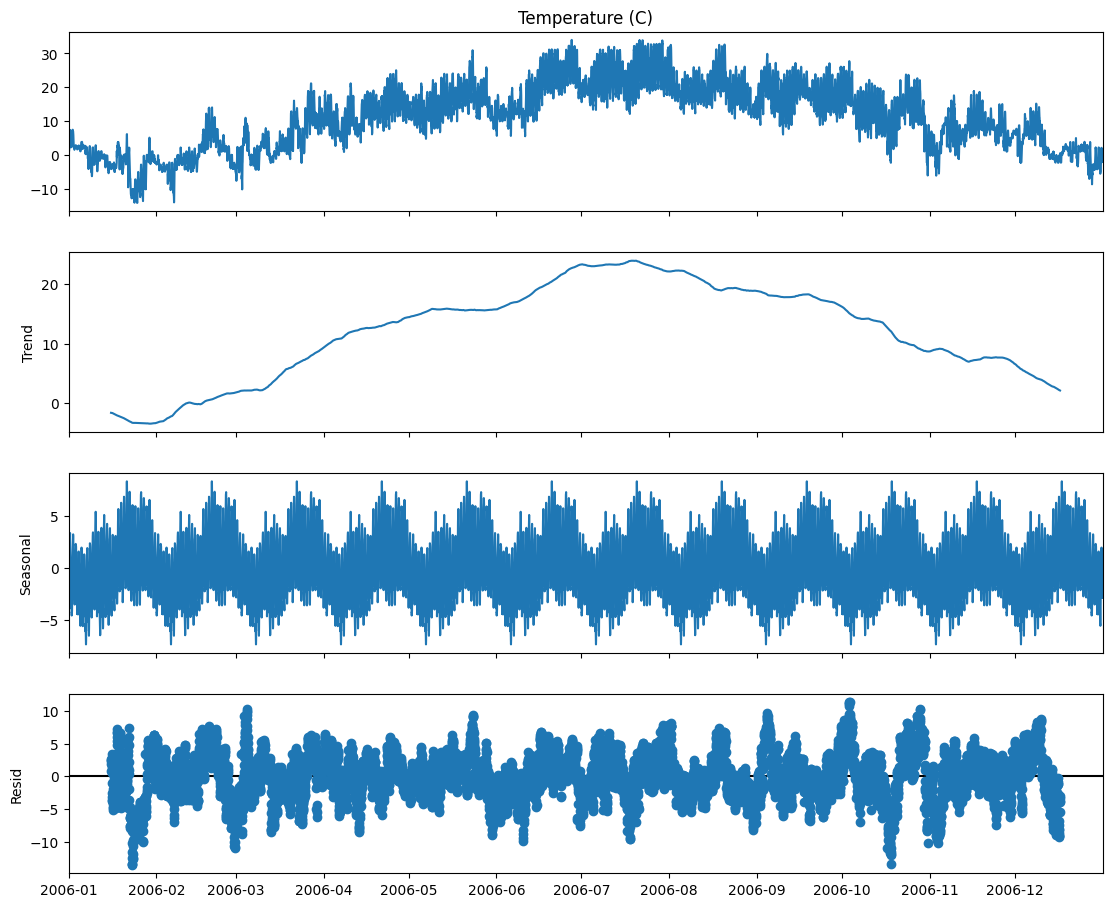

In [12]:
result = seasonal_decompose(df['Temperature (C)'][:24*365], model='additive', period=24*30)

fig = result.plot()
fig.set_size_inches(12, 10)
plt.show()

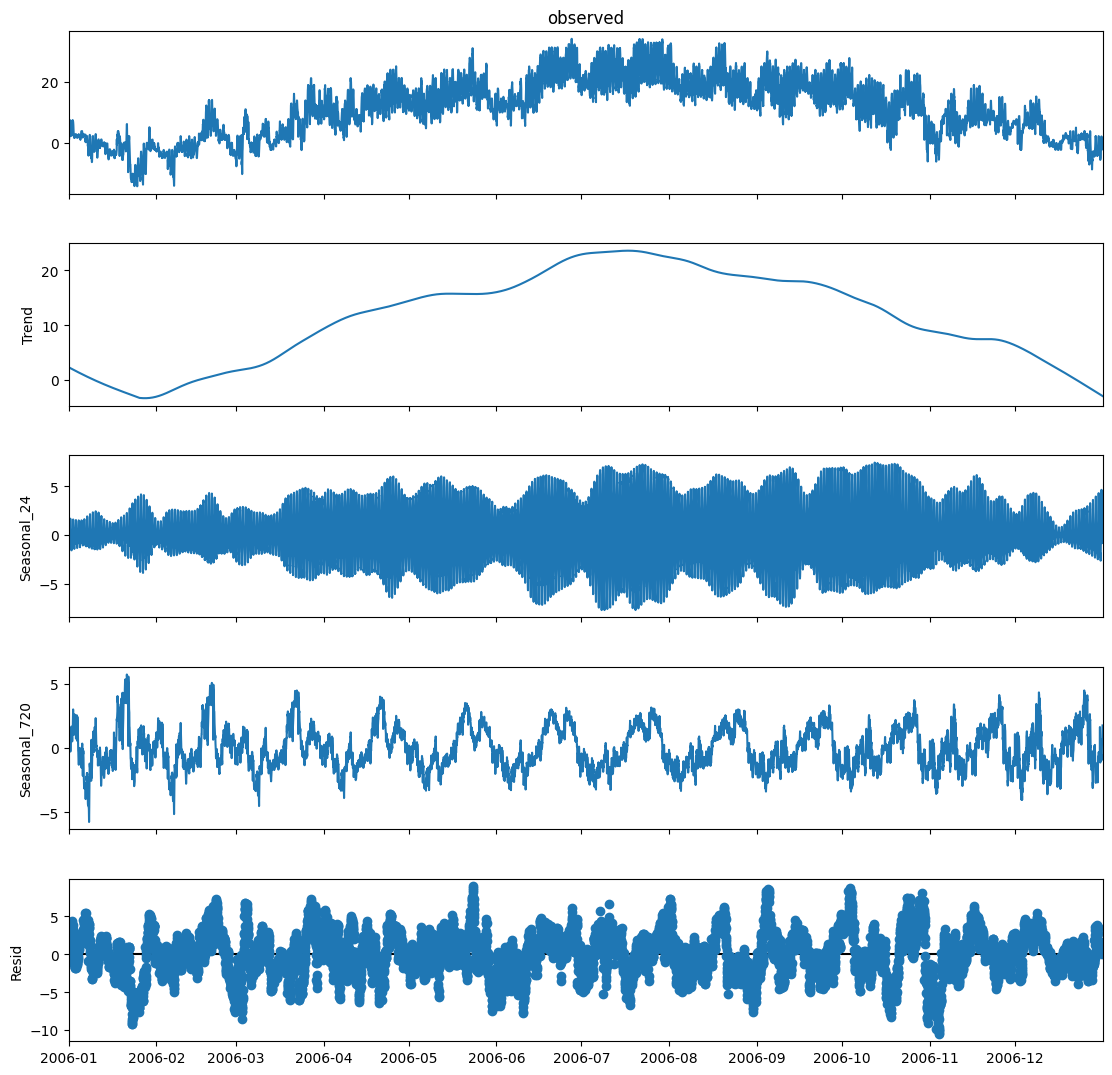

In [13]:
mstl = MSTL(df['Temperature (C)'][:24*365], periods=(24, 24*30))
result_mstl = mstl.fit()

fig = result_mstl.plot()
fig.set_size_inches(12, 12)
plt.show()

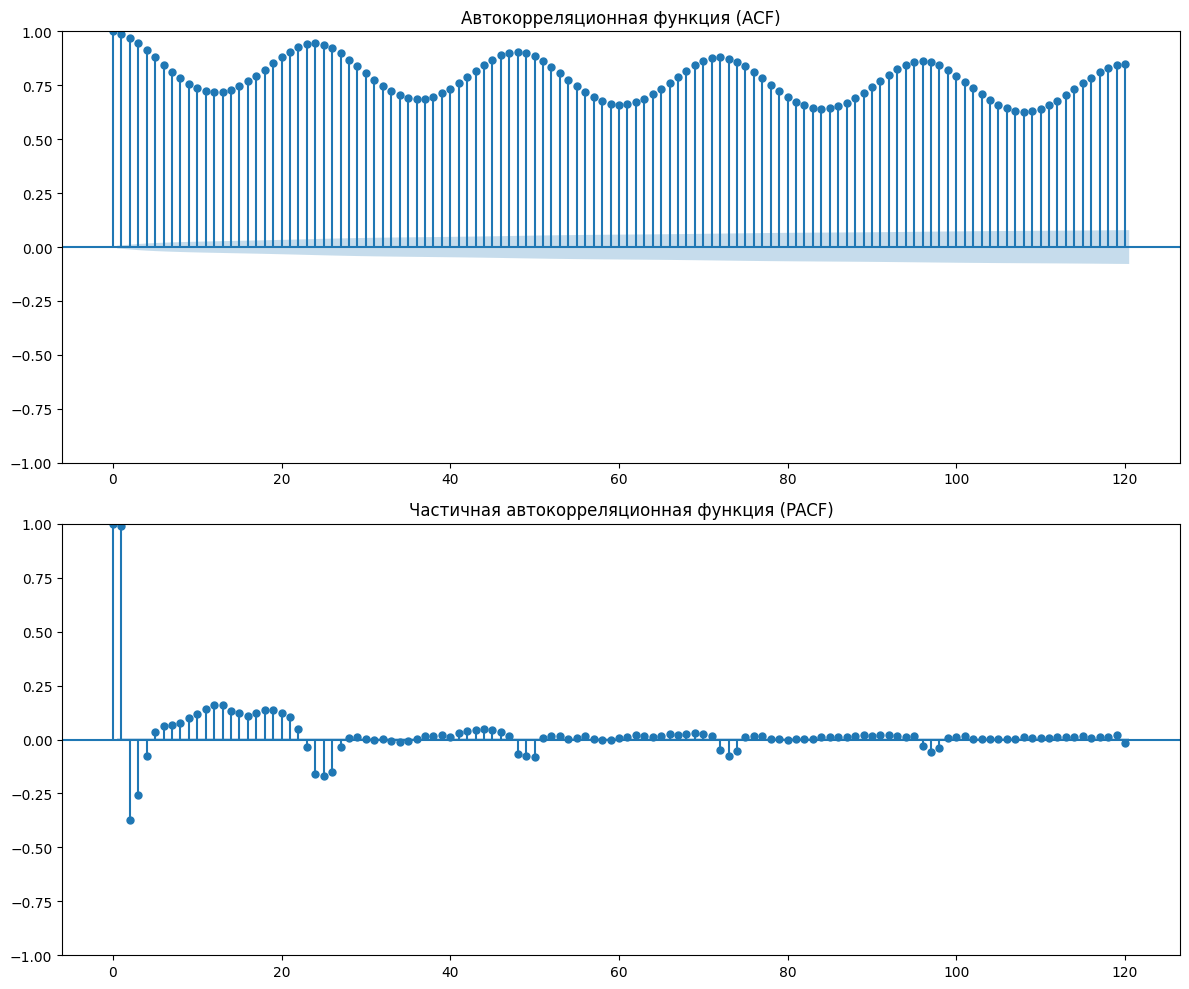

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

plot_acf(df['Temperature (C)'], lags=24*5, ax=ax[0])
plot_pacf(df['Temperature (C)'], lags=24*5, ax=ax[1])

ax[0].set_title('Автокорреляционная функция (ACF)')
ax[1].set_title('Частичная автокорреляционная функция (PACF)')
plt.tight_layout()
plt.show()

In [44]:
train_sarima = df['Temperature (C)'].iloc[-848:-48]
test_sarima = df['Temperature (C)'].iloc[-48:]

model_sarima = SARIMAX(train_sarima, 
                       order=(2, 0, 2), 
                       seasonal_order=(1, 1, 1, 24),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit(disp=False)
print(results_sarima.summary())

forecast_obj = results_sarima.get_forecast(steps=48)
sarima_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

mae_sarima = mean_absolute_error(test_sarima, sarima_pred)
mape_sarima = mean_absolute_percentage_error(test_sarima, sarima_pred)

print(f"SARIMA MAE:  {mae_sarima:.2f} MW")
print(f"SARIMA MAPE: {mape_sarima * 100:.2f}%")

                                      SARIMAX Results                                       
Dep. Variable:                      Temperature (C)   No. Observations:                  800
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood               -1039.558
Date:                              Sat, 07 Mar 2026   AIC                           2093.117
Time:                                      18:10:08   BIC                           2125.448
Sample:                                  05-25-2016   HQIC                          2105.575
                                       - 06-27-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3556      0.428      0.831      0.406      -0.483       1.195
ar.L2          0.58

In [45]:
forecast_obj = results_sarima.get_forecast(steps=48)
sarima_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

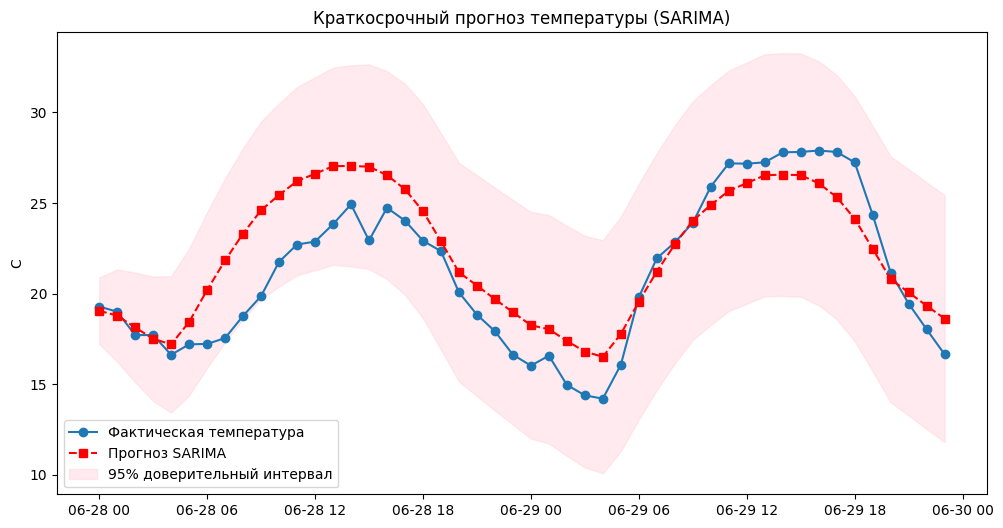

In [99]:
plt.figure(figsize=(12, 6))
plt.plot(test_sarima.index, test_sarima, label='Фактическая температура', marker='o')
plt.plot(test_sarima.index, sarima_pred, label='Прогноз SARIMA', color='red', linestyle='--', marker='s')
plt.fill_between(test_sarima.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% доверительный интервал')
plt.title('Краткосрочный прогноз температуры (SARIMA)')
plt.ylabel('C')
plt.legend()
plt.show()

In [ ]:
mae_sarima = mean_absolute_error(test_sarima, sarima_pred)
mape_sarima = mean_absolute_percentage_error(test_sarima, sarima_pred)

print(f"SARIMA MAE:  {mae_sarima:.2f} C")
print(f"SARIMA MAPE: {mape_sarima * 100:.2f}%")

SARIMA MAE:  1.80 MW
SARIMA MAPE: 8.93%


In [48]:
def create_features(df):
    df = df.copy()
    
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    
    df['lag_24'] = df['Temperature (C)'].shift(24)
    df['lag_168'] = df['Temperature (C)'].shift(168)
    
    df['rolling_mean_24'] = df['Temperature (C)'].shift(1).rolling(window=24).mean()
    
    return df

In [49]:
df_features = create_features(df).dropna()

print(f"Размер таблицы после генерации признаков: {df_features.shape}")
df_features.head()

Размер таблицы после генерации признаков: (91821, 15)


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),hour,dayofweek,month,quarter,lag_24,lag_168,rolling_mean_24
2006-01-08 00:00:00+01:00,-0.044444,-0.044444,0.96,3.7030,41.0,8.0500,0.0,1033.65,0,6,1,1,2.733333,0.577778,0.992824
2006-01-08 01:00:00+01:00,-4.094444,-6.794444,0.96,6.1824,340.0,6.6976,0.0,1035.67,1,6,1,1,0.294444,1.161111,0.877083
2006-01-08 02:00:00+01:00,-0.650000,-3.061111,0.96,6.7781,31.0,5.2164,0.0,1033.86,2,6,1,1,1.644444,1.666667,0.694213
2006-01-08 03:00:00+01:00,-1.161111,-3.605556,0.96,6.6654,30.0,4.2987,0.0,1033.96,3,6,1,1,0.527778,1.711111,0.598611
2006-01-08 04:00:00+01:00,-1.950000,-4.133333,0.96,5.7477,39.0,4.6851,0.0,1034.14,4,6,1,1,1.177778,1.183333,0.528241


In [ ]:
split_date = '2016-01-01'

train = df_features.loc[df_features.index < split_date]
test = df_features.loc[df_features.index >= split_date]

X_train = train.drop('Temperature (C)', axis=1)
y_train = train['Temperature (C)']

X_test = test.drop('Temperature (C)', axis=1)
y_test = test['Temperature (C)']

In [53]:
reg = XGBRegressor(base_score=0.5, 
                       booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:14.78954	validation_1-rmse:13.12170
[100]	validation_0-rmse:5.56866	validation_1-rmse:4.90070
[200]	validation_0-rmse:2.20538	validation_1-rmse:1.89645
[300]	validation_0-rmse:0.97201	validation_1-rmse:0.80250
[400]	validation_0-rmse:0.53294	validation_1-rmse:0.44274
[500]	validation_0-rmse:0.38053	validation_1-rmse:0.33785
[600]	validation_0-rmse:0.31911	validation_1-rmse:0.29375
[700]	validation_0-rmse:0.28392	validation_1-rmse:0.25920
[800]	validation_0-rmse:0.26100	validation_1-rmse:0.23676
[900]	validation_0-rmse:0.24435	validation_1-rmse:0.21936
[999]	validation_0-rmse:0.23320	validation_1-rmse:0.20671


,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [54]:
test = test.copy()
test['prediction'] = reg.predict(X_test)

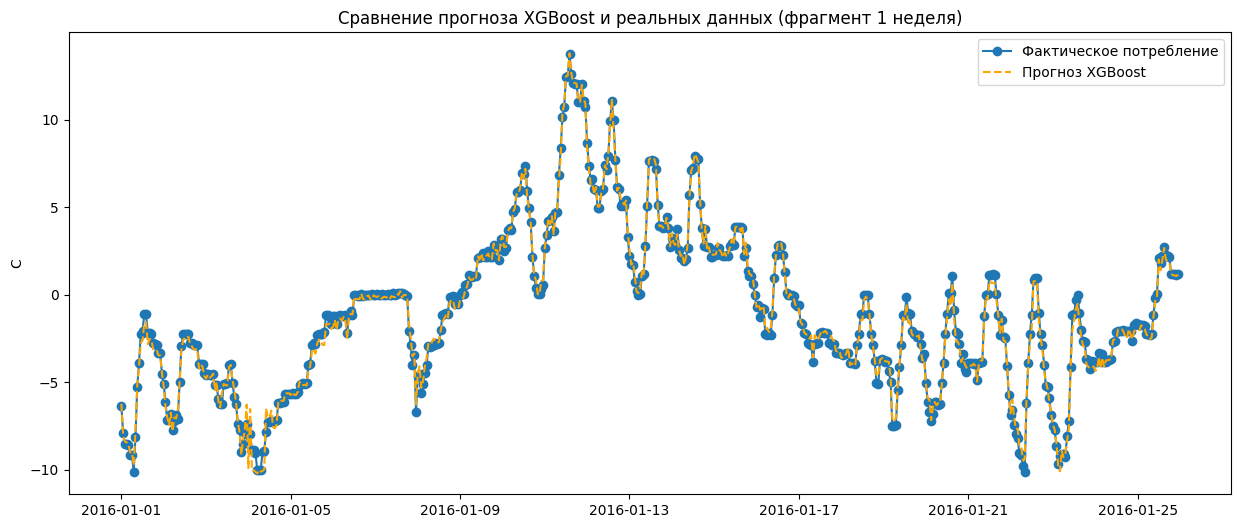

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test.index[:168], test['Temperature (C)'][:168], label='Фактическое потребление', marker='o')
plt.plot(test.index[:168], test['prediction'][:168], label='Прогноз XGBoost', color='orange', linestyle='--')
plt.title('Сравнение прогноза XGBoost и реальных данных (фрагмент 1 неделя)')
plt.ylabel('C')
plt.legend()
plt.show()

In [96]:
mask = np.abs(test['Temperature (C)']) > 0.5
mae_xgb = mean_absolute_error(test['Temperature (C)'][mask], test['prediction'][mask])
mape_xgb = mean_absolute_percentage_error(test['Temperature (C)'][mask], test['prediction'][mask])

print(f"MAE (filtered): {mae_xgb:.3f} C")
print(f"MAPE (filtered): {mape_xgb*100:.2f}%")

MAE (filtered): 0.137 C
MAPE (filtered): 2.88%


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train[['Temperature (C)']])
scaled_test = scaler.transform(test[['Temperature (C)']])

In [67]:
def create_sequences(data, window_size):
    """
    Преобразует одномерный массив в набор последовательностей фиксированной длины.
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

In [68]:
WINDOW_SIZE = 24

X_train_lstm, y_train_lstm = create_sequences(scaled_train, WINDOW_SIZE)
X_test_lstm, y_test_lstm = create_sequences(scaled_test, WINDOW_SIZE)

print(f"Форма обучающей выборки для LSTM: {X_train_lstm.shape}")

Форма обучающей выборки для LSTM: (87453, 24, 1)


In [69]:
model_lstm = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

In [70]:
model_lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [90]:
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - loss: 6.3382e-04 - val_loss: 2.3997e-04
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - loss: 6.1790e-04 - val_loss: 2.4071e-04
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - loss: 6.1083e-04 - val_loss: 2.2880e-04
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - loss: 6.1539e-04 - val_loss: 2.4250e-04
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - loss: 6.0448e-04 - val_loss: 2.4457e-04
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - loss: 6.0172e-04 - val_loss: 2.2702e-04
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 6.0010e-04 - val_loss: 2.3439e-04
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 69s 54ms/step - loss: 6.0268e-04 - val_loss: 2.3434e-04
Epoch 9/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - loss: 5.8869e-04 - val_loss: 2.5591e-04


In [91]:
lstm_predictions_scaled = model_lstm.predict(X_test_lstm)

lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)
y_test_lstm_real = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


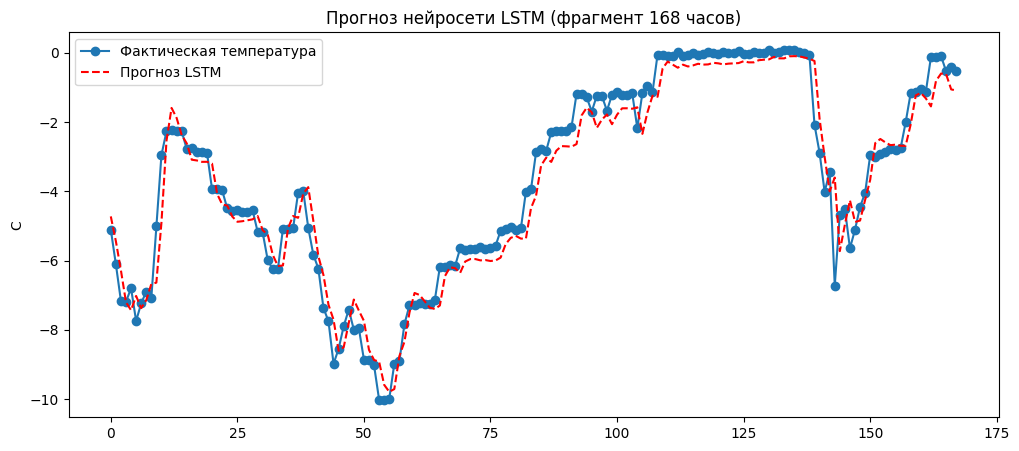

In [92]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_lstm_real[:168], label='Фактическая температура', marker='o')
plt.plot(lstm_predictions[:168], label='Прогноз LSTM', color='red', linestyle='--')
plt.title('Прогноз нейросети LSTM (фрагмент 168 часов)')
plt.ylabel('C')
plt.legend()
plt.show()

In [ ]:
mask = np.abs(y_test_lstm_real) > 0.5
mae_lstm= mean_absolute_error(y_test_lstm_real[mask], lstm_predictions[mask])
mape_lstm = mean_absolute_error(y_test_lstm_real[mask], lstm_predictions[mask]) / np.mean(np.abs(y_test_lstm_real[mask]))  

print(f"LSTM MAE (filtered) : {mae_lstm:.3f} C")
print(f"LSTM MAPE (filtered): {mape_lstm * 100:.2f}%")

LSTM MAE (filtered) : 0.718 C
LSTM MAPE (filtered): 6.14%


In [97]:
results_df = pd.DataFrame({
    'Модель': ['SARIMA', 'XGBoost', 'LSTM'],
    'MAE (C)': [mae_sarima, mae_xgb, mae_lstm],
    'MAPE (%)': [mape_sarima * 100, mape_xgb * 100, mape_lstm * 100]
})

results_df = results_df.round(2)
print("Сводная таблица точности моделей:")
print(results_df)

Сводная таблица точности моделей:
    Модель  MAE (C)  MAPE (%)
0   SARIMA     1.80      8.93
1  XGBoost     0.14      2.88
2     LSTM     0.72      6.14


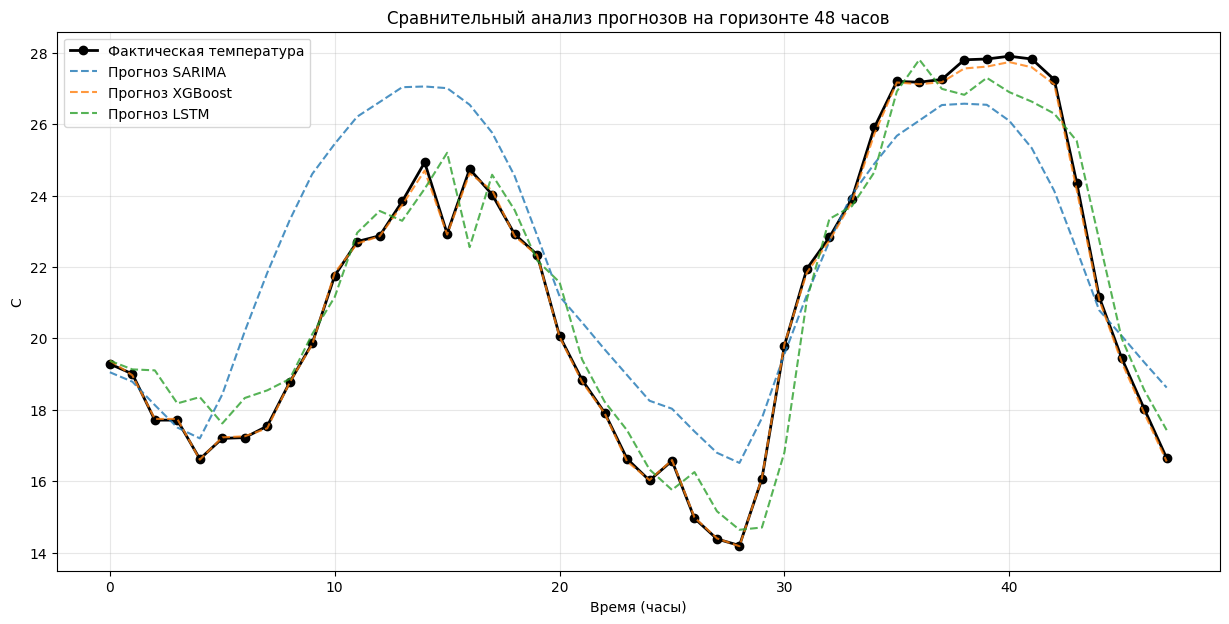

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(y_test_lstm_real[-48:], label='Фактическая температура', color='black', linewidth=2, marker='o')

plt.plot(sarima_pred[:48].values, label='Прогноз SARIMA', linestyle='--', alpha=0.8)
plt.plot(test['prediction'][-48:].values, label='Прогноз XGBoost', linestyle='--', alpha=0.8)
plt.plot(lstm_predictions[-48:], label='Прогноз LSTM', linestyle='--', alpha=0.8)

plt.title('Сравнительный анализ прогнозов на горизонте 48 часов')
plt.xlabel('Время (часы)')
plt.ylabel('C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()